**<center><font size=5>Exploring the beautiful side of Gradient Decent - Linear Regression</font></center>**

---

**Table of Contents**

- <a href='#intro'>1. Project Overview and Objectives</a>
  - <a href='#dataset'>1.1. Data Set Description</a>
- <a href='#env'>2. Setting up the Environment</a>
- <a href='#import'>3. Data Import</a>
  - <a href='#dataset'>3.1. Data Set visualization</a>
  - <a href='#dataset'>3.1. Data Set preprocessing</a>
- <a href='#cnn'>4. Initial params configuration</a>
- <a href='#cnn'>5. Gradient descent functions</a>
- <a href='#concl'>6. Loss visulization</a>
- <a href='#concl'>7. Conclusion</a>

---

All the credits goes to our TP instructors , Thanks a lot - I just modify and adapt the notebook to make it easy to learn , and I add my thoughts and ideas


# <a href='#intro'>1. Project Overview and Objectives</a>

## <a href='#dataset'>1.1. Data Set Description</a>

The California housing dataset consists of 20,640 observations from the 1990 U.S. Census, featuring 8 numerical attributes (such as median income, house age, and location) to predict median house values. It is commonly used for regression analysis and contains no missing values in the standard scikit-learn version.

Source: [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)


# <a href='#env'>2. Setting up the Environment</a>


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import pandas as pd

# <a href='#import'>3. Data Import and Preprocessing</a>


In [10]:
data = fetch_california_housing()

# Une seule variable explicative (feature 2 par exemple)
X = data.data
y = data.target

# Une seule variable explicative (MedInc)
X_feature = X[:, 0]

feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## <a href='#dataset'>3.1. Data Set visualization</a>


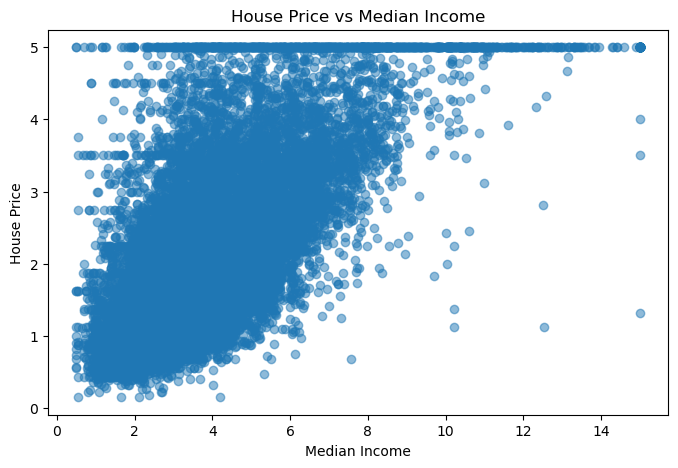

In [ ]:
X_feature = X[:, 0]  # MedInc

plt.figure(figsize=(8, 5))
plt.scatter(X_feature, y, alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("House Price vs Median Income")
plt.show()

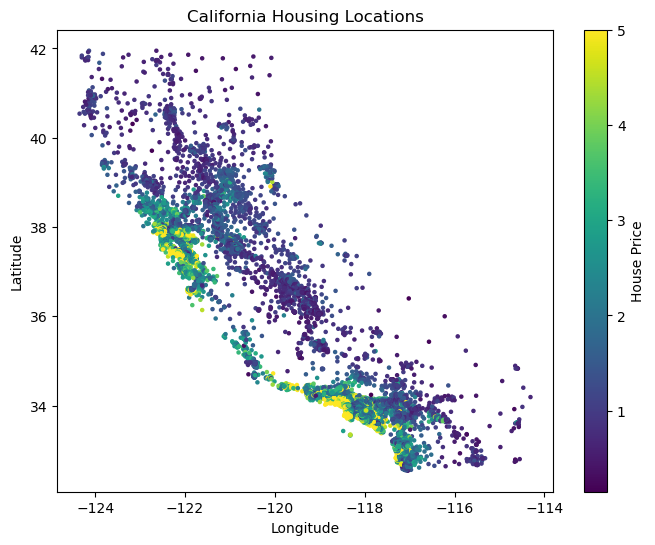

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Longitude"], df["Latitude"], c=y, s=5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Locations")
plt.colorbar(label="House Price")
plt.show()

## <a href='#dataset'>3.1. Data Set preprocessing</a>


In [ ]:
# Reshape + Standardisation
# La descente du gradient converge plus vite quand les features sont normalisées.
X_feature = X_feature.reshape(-1, 1)
scaler = StandardScaler()
X_feature = scaler.fit_transform(X_feature)

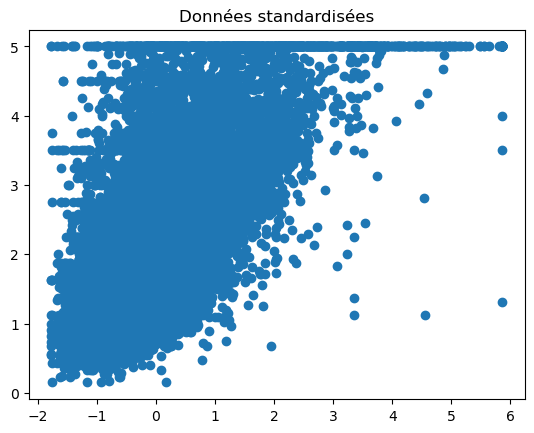

In [8]:
plt.figure()
plt.scatter(X_feature, y)
plt.title("Données standardisées")
plt.show()

# <a href='#cnn'>4. Initial params configuration</a>


In [ ]:
m = len(y)

# Ajout du biais (colonne de 1)
# hTx = theta0 + theta1.X : on crée une matrice de bias (1,X1);(1,X2);(1,X3).....
X = np.hstack((np.ones((m, 1)), X_feature))

# Initialisation des paramètres (theta0, theta1)
thetas = np.zeros(2)

learning_rate = 0.01
epochs = 1000

# <a href='#cnn'>5. Gradient descent functions</a>


In [15]:
def prediction(X, thetas):
    return X.dot(thetas)


def cost_function(X, y, thetas):
    m = len(y)
    errors = prediction(X, thetas) - y
    return (1 / (2 * m)) * np.sum(errors**2)


def gradients(X, y, thetas):
    m = len(y)
    errors = prediction(X, thetas) - y
    d_thetas = (1 / m) * X.T.dot(errors)
    return d_thetas

In [16]:
# Desente du gradient
cost_history = []
cost = cost_function(X, y, thetas)

for epoch in range(epochs):
    grad = gradients(X, y, thetas)
    thetas = thetas - learning_rate * grad
    cost = cost_function(X, y, thetas)
    cost_history.append(cost)

In [17]:
# Affichage des paramètres finaux
print("\nParamètres appris :")
print("theta0 =", thetas[0])
print("theta1 =", thetas[1])


Paramètres appris :
theta0 = 2.0684688668526454
theta1 = 0.7939551114525476


# <a href='#concl'>6. Loss visulization</a>


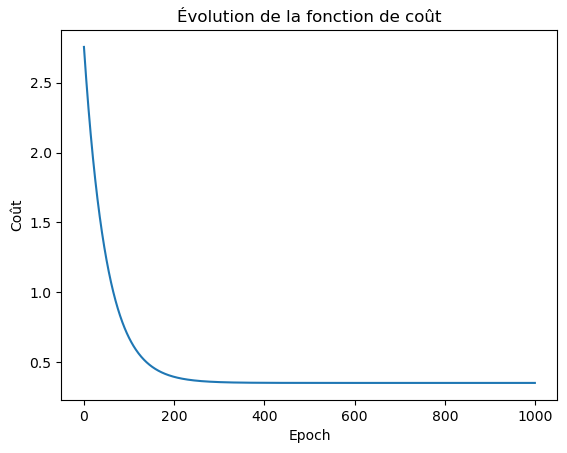

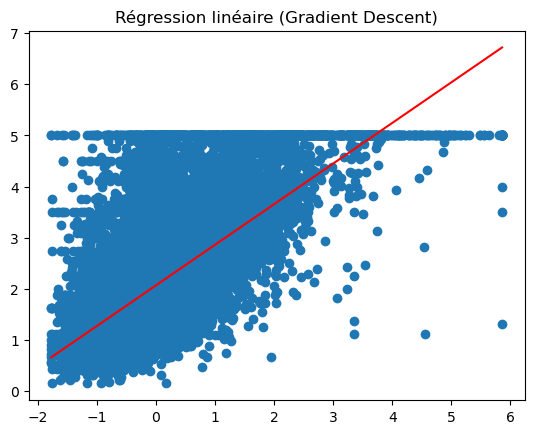

In [18]:
# Courbe de convergence
plt.plot(cost_history)
plt.title("Évolution de la fonction de coût")
plt.xlabel("Epoch")
plt.ylabel("Coût")
plt.show()


# ===============================
# Visualisation de la droite
# ===============================

plt.scatter(X_feature[:, 0], y)
x_line = np.linspace(X_feature.min(), X_feature.max(), 100)
x_line_bias = np.column_stack((np.ones(100), x_line))
y_line = prediction(x_line_bias, thetas)
plt.plot(x_line, y_line, color="red")
plt.title("Régression linéaire (Gradient Descent)")
plt.show()

I'll add my conclusions and comments here later
